# 1. Скачиваем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import os

# 2. Установка параметров

In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20

# 3. Загрузка датасета

In [3]:
# Создание списка категорий
categories = os.listdir('./flower_photos/')

In [4]:
# Создание функции загрузки данных
def load_data(folder, img_size):
    images, labels = [], []
    for category in categories:
        path = os.path.join(folder, category)
        label = categories.index(category)
        for img in os.listdir(path):
            img_array = tf.keras.preprocessing.image.load_img(os.path.join(path, img), target_size=(img_size, img_size))
            img_array = tf.keras.preprocessing.image.img_to_array(img_array)
            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

In [5]:
# Загрузка данных
images, labels = load_data('./flower_photos/', IMG_SIZE)

# 4. Подготовка данных к моделированию

In [6]:
# Нормализация данных (приведение значений пикселей к диапазону [0, 1])
images = images / 255.0

In [7]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# 5. Моделирование

In [8]:
# Создание модели на основе предобученной MobileNetV2
WEIGHTS_PATH_NO_TOP = './model/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_128_no_top.h5'
base_model = MobileNetV2(weights=WEIGHTS_PATH_NO_TOP, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

In [9]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Обучение модели

In [11]:
history = model.fit(X_train, y_train, epochs=EPOCHS, validation_split=0.2, batch_size=BATCH_SIZE)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.4981 - loss: 1.3829 - val_accuracy: 0.8333 - val_loss: 0.4681
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.8421 - loss: 0.4644 - val_accuracy: 0.8452 - val_loss: 0.5212
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9246 - loss: 0.2383 - val_accuracy: 0.8333 - val_loss: 0.5907
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9331 - loss: 0.2070 - val_accuracy: 0.8537 - val_loss: 0.5557
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9714 - loss: 0.0806 - val_accuracy: 0.8350 - val_loss: 0.7061
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9784 - loss: 0.0747 - val_accuracy: 0.8520 - val_loss: 0.8119
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.9848 - loss: 0.0447 - val_accuracy: 0.8537 - val_loss: 0.7754
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9888 - loss: 0.0370 - val_accuracy: 

# 7. Оценка качества модели на тестовой выборке

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Точность на тестовой выборке: {test_accuracy * 100:.2f}%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8486 - loss: 1.1438
Точность на тестовой выборке: 85.56%


# 8. Визуализация полученных результатов

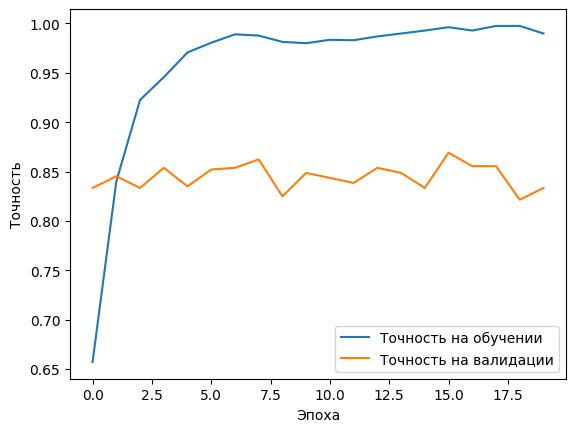

In [13]:
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()

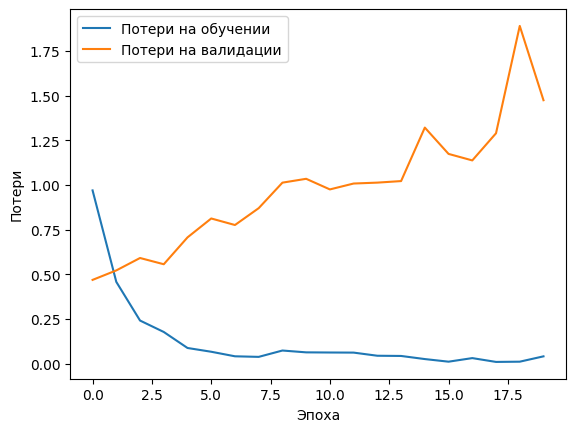

In [14]:
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.show()

# 9. Тестирование работы модели

In [19]:
def model_testing(path, img, img_size):
    img_load = tf \
        .keras \
        .preprocessing \
        .image \
        .load_img(os.path.join(path, img), target_size=(img_size, img_size))
    img_array = tf \
        .keras \
        .preprocessing \
        .image \
        .img_to_array(img_load)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=-1)[0]
    category_names = categories[predicted_class]
    plt.imshow(img_load)
    return category_names

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


'daisy'

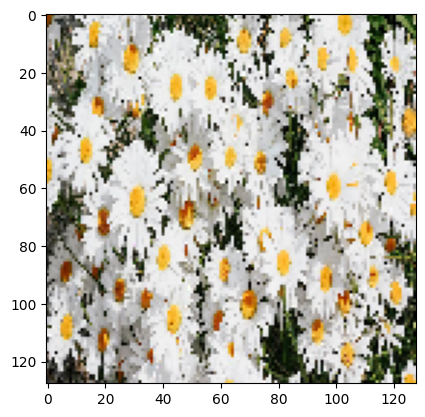

In [23]:
model_testing('./test_images', 'test_1.jpg', 128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


'tulips'

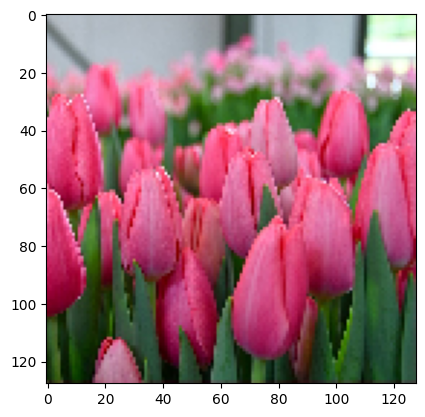

In [24]:
model_testing('./test_images', 'test_2.jpg', 128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


'sunflowers'

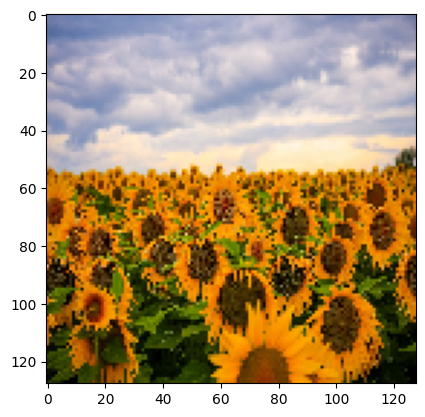

In [25]:
model_testing('./test_images', 'test_3.jpg', 128)